In [1]:
import numpy as np

# Function to sample proportions based on given probabilities
def sample_proportions(sample_size, proportions):
    # Define categories (e.g., Black, Non-Black)
    categories = ['Black', 'Non-Black']
    # Sample from the categories based on the specified proportions
    return np.random.choice(categories, size=sample_size, p=proportions)

# Parameters
sample_size = 100  # Sample size
eligible_population = [0.26, 0.74]  # Proportions for Black and Non-Black jurors

# Simulate one value of the statistic (proportion of Black jurors)
sample_proportion_black = sample_proportions(sample_size, eligible_population)

# Calculate the proportion of Black jurors in the sample
black_proportion = np.sum(sample_proportion_black == 'Black') / sample_size

# Display the result
print("Proportion of Black jurors in the random sample:", black_proportion)

# Run the simulation a few times to observe variations
for _ in range(5):
    sample_proportion_black = sample_proportions(sample_size, eligible_population)
    black_proportion = np.sum(sample_proportion_black == 'Black') / sample_size
    print("Simulated Proportion of Black jurors:", black_proportion)

Proportion of Black jurors in the random sample: 0.32
Simulated Proportion of Black jurors: 0.2
Simulated Proportion of Black jurors: 0.24
Simulated Proportion of Black jurors: 0.21
Simulated Proportion of Black jurors: 0.23
Simulated Proportion of Black jurors: 0.21


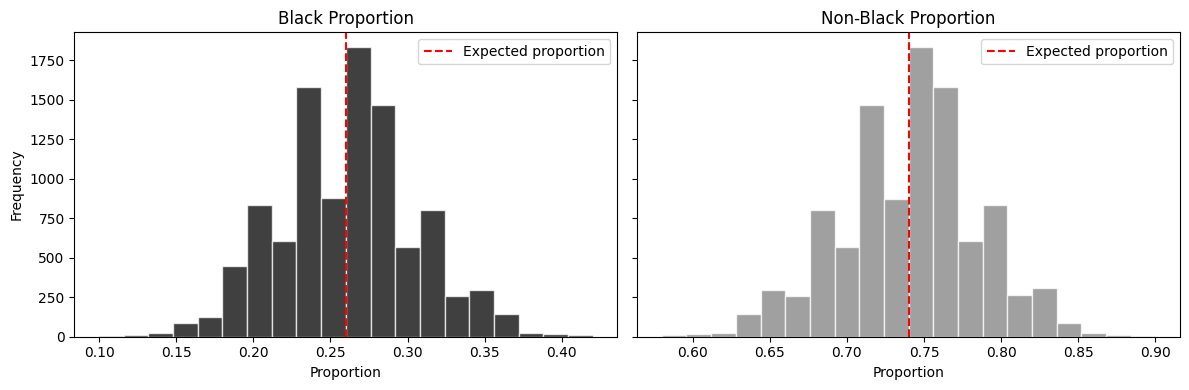

In [2]:
import matplotlib.pyplot as plt

# Simulate many samples and collect proportions for each category
n_simulations = 10000
black_proportions = np.empty(n_simulations)

for i in range(n_simulations):
    sample = sample_proportions(sample_size, eligible_population)
    black_proportions[i] = np.mean(sample == "Black")

non_black_proportions = 1 - black_proportions

# Plot histograms of the proportion distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(black_proportions, bins=20, color="black", alpha=0.75, edgecolor="white")
axes[0].axvline(eligible_population[0], color="red", linestyle="--", label="Expected proportion")
axes[0].set_title("Black Proportion")
axes[0].set_xlabel("Proportion")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(non_black_proportions, bins=20, color="gray", alpha=0.75, edgecolor="white")
axes[1].axvline(eligible_population[1], color="red", linestyle="--", label="Expected proportion")
axes[1].set_title("Non-Black Proportion")
axes[1].set_xlabel("Proportion")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Simulate 100 random panels of size 100 from a population with 26% Black jurors
n_draws = 100
observed_count = 8

black_counts = np.random.binomial(n=sample_size, p=eligible_population[0], size=n_draws)
p_at_most_observed = np.mean(black_counts <= observed_count)

# Visualize the distribution of Black counts
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(black_counts.min() - 0.5, black_counts.max() + 1.5, 1)

ax.hist(black_counts, bins=bins, color="black", alpha=0.8, edgecolor="white")
ax.axvline(observed_count, color="red", linestyle="--", linewidth=2, label=f"Observed = {observed_count}")
ax.axvline(sample_size * eligible_population[0], color="blue", linestyle="--", linewidth=2, label="Expected = 26")

ax.set_title("Distribution of Black panelist counts (100 simulated panels)")
ax.set_xlabel("Number of Black panelists in a panel of 100")
ax.set_ylabel("Frequency")
ax.legend()

print(f"Simulated P(count <= {observed_count}) = {p_at_most_observed:.3f}")
plt.show()

Simulated P(count <= 8) = 0.000


KeyboardInterrupt: 